# Where were the nodes? Select by area and time, then cut the waveforms

Workflow for a hard drive full of SmartSolo data whose origin you are not sure about:

1. **Find all `DigiSolo.LOG` files** and turn them into a table of *deployments* (one per power-up) with the first stable GPS position and the time span.
2. **Select deployments** within a radius of a point or inside a polygon (`geopandas.sjoin`), optionally within a time window.
3. **Index the MiniSEED / SEG-Y files** (headers only) and **cut out** the selected time windows for the selected nodes with ObsPy.
4. Write MiniSEED, a station table (CSV / GeoPackage) and StationXML.

The waveform files here are synthetic (made by `scripts/make_synthetic_waveforms.py`) but cover the real deployment times and positions from the two sample logs.


In [28]:
import sys
sys.path.insert(0, "../lib")
sys.path.insert(0, "../scripts")
import warnings; warnings.filterwarnings("ignore", message="CREATING TRACE HEADER")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import smartsolo_log as sl
import smartsolo_locate as loc
import smartsolo_waveforms as wf

pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)

# make the synthetic waveform files once (not committed to git)
if not Path("../data/seismic_traces").exists():
    import make_synthetic_waveforms as mk
    mk.main("../data/seismic_traces")

# the two DML (Dronning Maud Land) nodes used in this notebook
DML_NODES = ["../data/nodes/453021267", "../data/nodes/453022522"]

## 1. Logs → deployments
`find_logs` searches recursively and checks file contents, so the logs can have any name and sit anywhere on the drive.

In [29]:
logs = loc.find_logs(DML_NODES)
logs

[PosixPath('../data/nodes/453021267/DigiSolo.LOG'),
 PosixPath('../data/nodes/453022522/DigiSolo.LOG')]

In [30]:
deps = loc.build_deployments(logs)          # add cache="deployments.gpkg" for a big drive
deps.drop(columns=["log_file", "geometry"])

,deployment_id,serial,session,start,end,n_records,n_fixes,latitude,longitude,elevation,fix_time,unstable_fixes_skipped,median_offset_m,max_offset_m,drift_m,drift_m_per_day,boot_reason,device_type,firmware_version,sample_rate,sample_rate_hz,channel_1_gain,channel_2_gain,channel_3_gain,geophone_ok,geophone_test_noisy,test_resonate_freq_hz_mean,test_damping_mean,test_sensitivity_mean,test_resistance_ohm_mean,tilted_angle_median,roll_angle_median,pitch_angle_median,ecompass_north_median,ecompass_north_std,duration
0,453021267_004,453021267,4,2024-12-25 14:26:27+00:00,2025-01-08 09:03:48+00:00,9914,2446,-71.548243,11.115678,1649.4,2024-12-25 14:34:23+00:00,0.0,1.965700,7.987803,2.576981,0.194169,0300,IGU-16HR 3C 5Hz,V1.0.8.1be,100.0,1000.0,0.0,0.0,0.0,True,False,5.230233,0.709500,73.801000,1617.033333,1.6715,1.663,0.115,156.669685,0.919373,13 days 18:37:21
1,453022522_003,453022522,3,2024-12-25 15:20:06+00:00,2025-01-08 10:09:20+00:00,9880,2447,-71.550005,11.117645,1643.7,2024-12-25 15:44:13+00:00,2.0,2.517204,8.434686,3.056145,0.230378,0300,IGU-16HR 3C 5Hz,V1.0.8.1be,100.0,1000.0,0.0,0.0,0.0,False,True,4.764167,0.639633,68.625567,1627.333333,5.1290,2.861,4.254,126.436865,0.876101,13 days 18:49:14


### Why the *first stable* fix?
Right after a cold start, the first GPS fixes can be far off. Node 453022522's first two fixes are ~45-100 m from where it settles, so they are skipped (`unstable_fixes_skipped = 2`). After that teh position wanders by a few metres (GPS noise + ice flow); `drift_m` compares the last day of fixes to the power-up position.

/var/folders/64/9b359m2n41d9ywlsbcs4s7rc0000gn/T/ipykernel_55648/2058726690.py:6: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  sc = ax.scatter(x, y, c=(g.index - g.index[0]) / pd.Timedelta("1D"), s=4, cmap="viridis")
/var/folders/64/9b359m2n41d9ywlsbcs4s7rc0000gn/T/ipykernel_55648/2058726690.py:6: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  sc = ax.scatter(x, y, c=(g.index - g.index[0]) / pd.Timedelta("1D"), s=4, cmap="viridis")


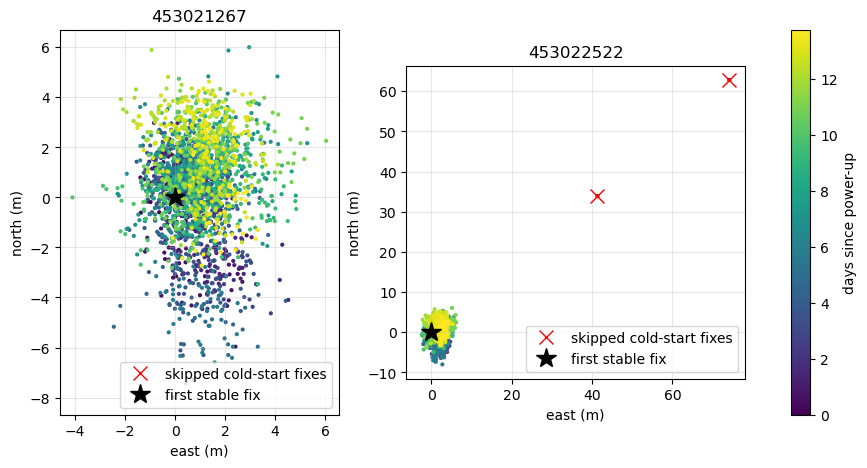

In [31]:
df = sl.read_logs(DML_NODES)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (serial, g) in zip(axes, df[df.latitude.notna()].groupby("serial")):
    d = deps[deps.serial == serial].iloc[0]
    x, y = loc._local_xy(g.latitude, g.longitude, d.latitude, d.longitude)
    sc = ax.scatter(x, y, c=(g.index - g.index[0]) / pd.Timedelta("1D"), s=4, cmap="viridis")
    ax.plot(x[:int(d.unstable_fixes_skipped)], y[:int(d.unstable_fixes_skipped)], "rx", ms=10,
            label="skipped cold-start fixes")
    ax.plot(0, 0, "k*", ms=15, label="first stable fix")
    ax.set(title=serial, xlabel="east (m)", ylabel="north (m)", aspect="equal")
    ax.legend(loc="lower right"); ax.grid(alpha=.3)
fig.colorbar(sc, ax=axes, label="days since power-up");

## 2. Select by radius, polygon and time

In [32]:
centre = (-71.549, 11.117)                      # (lat, lon)
sel_r = loc.select_deployments(deps, point=centre, radius_km=0.11)
sel_r[["deployment_id", "latitude", "longitude", "distance_km", "sel_start", "sel_end"]]

,deployment_id,latitude,longitude,distance_km,sel_start,sel_end
0,453021267_004,-71.548243,11.115678,0.096499,2024-12-25 14:26:27+00:00,2025-01-08 09:03:48+00:00


A polygon can be a list of `(lon, lat)` vertices, a shapely geometry, a GeoDataFrame or any file `geopandas.read_file` reads (GeoPackage, Shapefile, GeoJSON, KML, ...). Here we save one as GeoJSON and select from the file:

In [33]:
import geopandas as gpd
from shapely.geometry import Polygon

poly = gpd.GeoDataFrame({"name": ["upper_site"]},
                        geometry=[Polygon([(11.112, -71.5495), (11.119, -71.5495),
                                           (11.119, -71.5470), (11.112, -71.5470)])], crs="EPSG:4326") #square 
poly.to_file("../data/example_area.geojson", driver="GeoJSON")

sel_p = loc.select_deployments(deps, polygon="../data/example_area.geojson",
                               start="2024-12-26T00:00", end="2024-12-26T02:00")
sel_p[["deployment_id", "name", "sel_start", "sel_end"]]

,deployment_id,name,sel_start,sel_end
0,453021267_004,upper_site,2024-12-26 00:00:00+00:00,2024-12-26 02:00:00+00:00


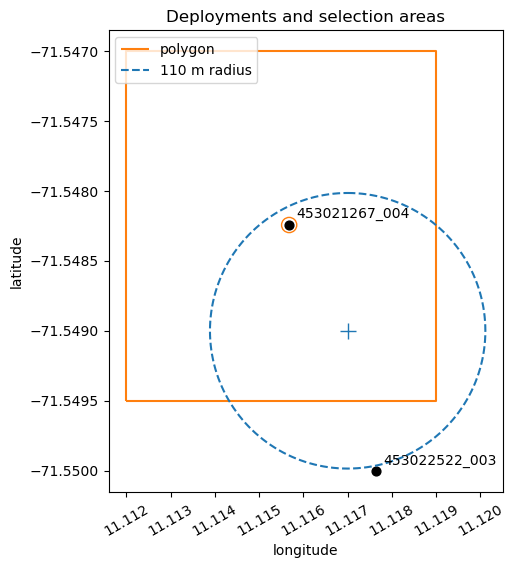

In [34]:
ax = poly.boundary.plot(color="C1", figsize=(6, 6), label="polygon")
deps.plot(ax=ax, color="k", markersize=40)
sel_p.plot(ax=ax, color="C1", markersize=120, marker="o", facecolor="none")
# radius circle (geodesic) around the centre
from pyproj import Geod
lons, lats, _ = Geod(ellps="WGS84").fwd(np.full(361, centre[1]), np.full(361, centre[0]),
                                        np.arange(361), np.full(361, 110.0))
ax.plot(lons, lats, "C0--", label="110 m radius"); ax.plot(centre[1], centre[0], "C0+", ms=12)
for _, d in deps.iterrows():
    ax.annotate(d.deployment_id, (d.longitude, d.latitude), xytext=(5, 5), textcoords="offset points")
ax.set(xlabel="longitude", ylabel="latitude", title="Deployments and selection areas")
ax.set_aspect(1 / np.cos(np.radians(centre[0])))   # metres equal in x and y
ax.ticklabel_format(useOffset=False); ax.tick_params(axis="x", rotation=30); ax.legend(loc="upper left");

Time-only or serial-only selections work too, and everything can be combined:

In [35]:
loc.select_deployments(deps, start="2025-01-08T09:30", end="2025-01-09")[["deployment_id", "sel_start", "sel_end"]]

,deployment_id,sel_start,sel_end
1,453022522_003,2025-01-08 09:30:00+00:00,2025-01-08 10:09:20+00:00


## 3. Index the waveform files
Only headers are read. The serial is taken from the file or folder name (9 digits), since raw exports often have empty station codes. With `cache=...` the index is stored and only new or changed files are read next time.

In [36]:
!find ../data/seismic_traces -type f | sort | head -5

../data/seismic_traces/.DS_Store
../data/seismic_traces/453021267/453021267.0001.2024.12.26.00.00.00.000.E.miniseed
../data/seismic_traces/453021267/453021267.0001.2024.12.26.00.00.00.000.N.miniseed
../data/seismic_traces/453021267/453021267.0001.2024.12.26.00.00.00.000.Z.miniseed
../data/seismic_traces/453021267/453021267.0002.2024.12.26.01.00.00.000.E.miniseed


In [37]:
index = wf.index_waveforms("../data/seismic_traces", cache="../output/waveform_index.csv")
index.groupby(["serial", "format", "component"]).agg(
    files=("path", "nunique"), start=("starttime", "min"), end=("endtime", "max"))

files                     start                              end
serial    format component                                                                  
453021267 MSEED  E              2 2024-12-26 00:00:00+00:00 2024-12-26 01:59:59.990000+00:00
                 N              2 2024-12-26 00:00:00+00:00 2024-12-26 01:59:59.990000+00:00
                 Z              2 2024-12-26 00:00:00+00:00 2024-12-26 01:59:59.990000+00:00
453022522 SEGY   E             12 2024-12-26 00:00:00+00:00 2024-12-26 00:59:59.990000+00:00
                 N             12 2024-12-26 00:00:00+00:00 2024-12-26 00:59:59.990000+00:00
                 Z             12 2024-12-26 00:00:00+00:00 2024-12-26 00:59:59.990000+00:00

## 4. Cut the waveforms
Codes come from the mapping table `data/station_mapping.csv`. Channel codes follow SEED: 100 Hz geophone → `EP?`.

In [38]:
print(open("../data/station_mapping.csv").read())

# serial -> SEED codes. location, channel_prefix, start, end are optional
serial,network,station,location,channel_prefix,start,end
453021267,XX,GL01,,,,
453022522,XX,GL02,,,,



In [39]:
sel = loc.select_deployments(deps, point=centre, radius_km=1,
                             start="2024-12-26T00:12:00", end="2024-12-26T00:13:30")
st = wf.extract_waveforms(sel, index, mapping="../data/station_mapping.csv",
                          out_dir="../output/mseed")
print(st)
print(st[0].stats.coordinates, st[0].stats.serial, st[0].stats.deployment_id)

6 Trace(s) in Stream:
XX.GL01..EPE | 2024-12-26T00:12:00.000000Z - 2024-12-26T00:13:29.990000Z | 100.0 Hz, 9000 samples
XX.GL01..EPN | 2024-12-26T00:12:00.000000Z - 2024-12-26T00:13:29.990000Z | 100.0 Hz, 9000 samples
XX.GL01..EPZ | 2024-12-26T00:12:00.000000Z - 2024-12-26T00:13:29.990000Z | 100.0 Hz, 9000 samples
XX.GL02..EPE | 2024-12-26T00:12:00.000000Z - 2024-12-26T00:13:29.990000Z | 100.0 Hz, 9000 samples
XX.GL02..EPN | 2024-12-26T00:12:00.000000Z - 2024-12-26T00:13:29.990000Z | 100.0 Hz, 9000 samples
XX.GL02..EPZ | 2024-12-26T00:12:00.000000Z - 2024-12-26T00:13:29.990000Z | 100.0 Hz, 9000 samples
AttribDict({'latitude': -71.548243333, 'longitude': 11.115677667, 'elevation': 1649.4}) 453021267 453021267_004


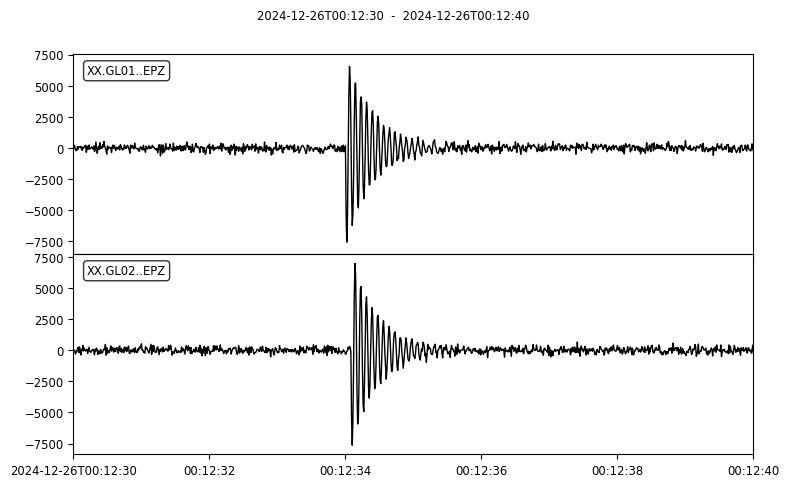

In [40]:
st.select(component="Z").copy().trim(st[0].stats.starttime + 30, st[0].stats.starttime + 40).plot();

In [41]:
st.written_files

[PosixPath('../output/mseed/XX/GL01/XX.GL01..EPE__20241226T001200Z__20241226T001330Z.mseed'),
 PosixPath('../output/mseed/XX/GL01/XX.GL01..EPN__20241226T001200Z__20241226T001330Z.mseed'),
 PosixPath('../output/mseed/XX/GL01/XX.GL01..EPZ__20241226T001200Z__20241226T001330Z.mseed'),
 PosixPath('../output/mseed/XX/GL02/XX.GL02..EPE__20241226T001200Z__20241226T001330Z.mseed'),
 PosixPath('../output/mseed/XX/GL02/XX.GL02..EPN__20241226T001200Z__20241226T001330Z.mseed'),
 PosixPath('../output/mseed/XX/GL02/XX.GL02..EPZ__20241226T001200Z__20241226T001330Z.mseed')]

For long windows, split the output into e.g. daily or hourly files and don't keep everything in memory:

In [42]:
_ = wf.extract_waveforms(sel.assign(sel_start=pd.Timestamp("2024-12-26T00:00", tz="UTC"),
                                     sel_end=pd.Timestamp("2024-12-26T02:00", tz="UTC")),
                         index, mapping="../data/station_mapping.csv", components=["Z"],
                         out_dir="../output/mseed_hourly", chunk="1h", return_stream=False)
sorted(p.name for p in Path("../output/mseed_hourly").rglob("*.mseed"))

['XX.GL01..EPZ__20241226T000000Z__20241226T010000Z.mseed',
 'XX.GL01..EPZ__20241226T010000Z__20241226T020000Z.mseed',
 'XX.GL02..EPZ__20241226T000000Z__20241226T010000Z.mseed']

## 5. StationXML and station table

In [43]:
inv = wf.build_inventory(sel, mapping="../data/station_mapping.csv", stream=st)
inv.write("../output/stations.xml", format="STATIONXML")
loc.export_stations(sel, "../output/stations.csv")
loc.export_stations(sel, "../output/stations.gpkg")      # open in QGIS
print(inv)

Inventory created at 2026-10-06T09:54:35.367328Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: node_toolbox
	Contains:
		Networks (1):
			XX
		Stations (2):
			XX.GL01 (SmartSolo 453021267 (453021267_004))
			XX.GL02 (SmartSolo 453022522 (453022522_003))
		Channels (6):
			XX.GL01..EPZ, XX.GL01..EPN, XX.GL01..EPE, XX.GL02..EPZ, 
			XX.GL02..EPN, XX.GL02..EPE


## 6. Everything in one call

In [44]:
sel, st, inv = wf.extract_region(
    log_root=DML_NODES, waveform_root="../data/seismic_traces",
    mapping="../data/station_mapping.csv",
    polygon="../data/example_area.geojson",
    start="2024-12-26T00:47:00", end="2024-12-26T00:48:00",
    out_dir="../output/upper_site")
print(st)
sorted(str(p.relative_to("../output/upper_site")) for p in Path("../output/upper_site").rglob("*") if p.is_file())

3 Trace(s) in Stream:
XX.GL01..EPE | 2024-12-26T00:47:00.000000Z - 2024-12-26T00:47:59.990000Z | 100.0 Hz, 6000 samples
XX.GL01..EPN | 2024-12-26T00:47:00.000000Z - 2024-12-26T00:47:59.990000Z | 100.0 Hz, 6000 samples
XX.GL01..EPZ | 2024-12-26T00:47:00.000000Z - 2024-12-26T00:47:59.990000Z | 100.0 Hz, 6000 samples


['mseed/XX/GL01/XX.GL01..EPE__20241226T004700Z__20241226T004800Z.mseed',
 'mseed/XX/GL01/XX.GL01..EPN__20241226T004700Z__20241226T004800Z.mseed',
 'mseed/XX/GL01/XX.GL01..EPZ__20241226T004700Z__20241226T004800Z.mseed',
 'stations.csv',
 'stations.gpkg',
 'stations.xml']